# Predicting Unusual Household and Housing Profiles Related to Social Tenancy Risk Using Machine Learning
Ahmed Zaus Zahid, Afnan Ali, Aminath Iuzaaz Ismail



## Overview

This project explores whether machine learning can flag households in subsidised social housing whose profiles are unusual in ways associated with tenancy misuse (illegal subletting and eligibility fraud), producing a **graded risk score for human review** rather than a definitive fraud determination.

**Data.** American Housing Survey (AHS) 2023 National Public Use File, U.S. Census Bureau (`household.csv`, one row per housing unit). The AHS is used because no public dataset of confirmed social-housing fraud exists and Maldivian tenancy records are not publicly available; a well-documented proxy is therefore required.

**Dependencies.** `pandas`, `scikit-learn`, `imbalanced-learn`, `matplotlib`.

**Missing codes.** The AHS stores every value as a numeric code. Negative values (`-6`, `-9`) are reserved "not applicable / not reported" markers, not real measurements, and are converted to `NaN` before analysis.

### Loading the data
The AHS dataset is a massive dataset. However, most of the data is not related to our specific usecase and we will not be needing them. Before we can train our models on the data, we need to identify which columns we need and treat the data which requires cleaning. 

In [1]:
import pandas as pd

poop = pd.read_csv("household.csv")
poop.head()

,CONTROL,TOTROOMS,PERPOVLVL,JACPRIMARY,JACSECNDRY,JADEQUACY,JAIRRATE,JBATHEXCLU,JBATHROOMS,JBEDROOMS,...,PROTAXAMT,INSURAMT,HOAAMT,LOTAMT,MAINTAMT,MORTAMT,HINCP,FINCP,REMODAMT,TOTHCAMT
0,'11000002',6,-6,'0','0','2','0','0','0','0',...,-6,-6,-6,-6,-6,-6,-6,-6,-6,-6
1,'11000003',4,199,'0','0','2','0','0','0','0',...,-6,13,-6,-6,-6,-6,48000,48000,-6,1093
2,'11000005',7,501,'0','0','2','0','0','0','0',...,245,267,21,-6,201,-6,292500,292500,500,810
3,'11000006',5,232,'0','0','2','0','0','0','0',...,122,59,0,-6,458,-6,56000,56000,20000,489
4,'11000008',3,231,'2','2','2','0','0','0','0',...,-6,41,-6,-6,-6,-6,36000,36000,-6,845


In [2]:
import pandas as pd

# the columns we need from the dataset
ahs_cols = [
    "CONTROL", "TENURE", "WEIGHT",
    "HUDSUB", "RENTSUB", "RENTCNTRL",
    "HINCP", "FINCP", "PERPOVLVL", "FS",
    "NUMPEOPLE", "BEDROOMS", "TOTROOMS",
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS", "UNITSIZE",
    "RENT", "TOTHCAMT", "UTILAMT",
    "HIAFFORD", "HIBEHINDFRQ", "HIHALF", "HINUMOVE",
    "HIEVICNOTE", "HIEVICTHT", "HIEVICLK", "HINOWHERE",
    "MGRONSITE",
    "NUMNONREL", "NUMSECFAM", "NUMSUBFAM",
    "OCCJANUR", "OCCFEBRU", "OCCMARCH", "OCCAPRIL", "OCCMAY", "OCCJUNE",
    "OCCJULY", "OCCAUGUST", "OCCSEPTEM", "OCCOCTOB", "OCCNOVEM", "OCCDECEM",
    "OCCYRRND", "MONLSTOCC", "VACMONTHS",
]

df = pd.read_csv(
    "household.csv",             # AHS 2023 national PUF file
    quotechar="'",               # strips the single quotes around every value
    usecols=lambda c: c in ahs_cols,   # only load these columns
)


print(df.shape)
print(df.head())

(55669, 48)
    CONTROL  TOTROOMS  PERPOVLVL  RENT  TENURE  HIEVICLK  HIAFFORD  HIHALF  \
0  11000002         6         -6  1600      -6        -6        -6      -6   
1  11000003         4        199   840       2         4         4       2   
2  11000005         7        501    -6       1        -6        -6      -6   
3  11000006         5        232    -6       1        -6        -6      -6   
4  11000008         3        231   800       2         2         2       1   

   OCCJANUR  OCCFEBRU  ...  HIBEHINDFRQ  HINOWHERE  HIEVICTHT  HIEVICNOTE  \
0         1         1  ...           -6         -6         -6          -6   
1        -6        -6  ...            6          0          2          -6   
2        -6        -6  ...           -6          0         -6          -6   
3        -6        -6  ...           -6         -6         -6          -6   
4        -6        -6  ...            2          0          1           1   

   HINUMOVE  MGRONSITE  HUDSUB   HINCP   FINCP  TOTHCAMT

Running the cell, we can already see that our data needs cleaning even though the printed section is only a small slice of the full data. The AHS dataset uses -6 and -9 to represent Null values.

### Analysing the data for cleaning

In [3]:
r = df[df["TENURE"] == 2].replace([-6, -9], pd.NA)   # renters only, codes -> NaN
missing = r.isna().mean().sort_values(ascending=False)
print((missing * 100).round(1))
print("renter rows:", len(r))

OCCAUGUST      100.0
OCCJULY        100.0
OCCJUNE        100.0
OCCMAY         100.0
OCCAPRIL       100.0
OCCMARCH       100.0
OCCFEBRU       100.0
OCCJANUR       100.0
OCCDECEM       100.0
VACMONTHS      100.0
MONLSTOCC      100.0
OCCYRRND       100.0
OCCOCTOB       100.0
OCCNOVEM       100.0
OCCSEPTEM      100.0
HIEVICNOTE      98.1
RENTCNTRL       87.6
HIHALF          52.6
HIEVICLK        51.7
HIAFFORD        51.7
HIBEHINDFRQ     51.6
HINOWHERE       51.6
HIEVICTHT       51.5
HINUMOVE        50.7
MGRONSITE       31.0
FS              30.0
UNITSIZE        18.0
RENTSUB          2.0
TENURE           0.0
PERPOVLVL        0.0
TOTROOMS         0.0
CONTROL          0.0
RENT             0.0
NUMSUBFAM        0.0
NUMOLDKIDS       0.0
NUMYNGKIDS       0.0
NUMNONREL        0.0
NUMADULTS        0.0
NUMELDERS        0.0
WEIGHT           0.0
NUMSECFAM        0.0
UTILAMT          0.0
NUMPEOPLE        0.0
BEDROOMS         0.0
HUDSUB           0.0
HINCP            0.0
FINCP            0.0
TOTHCAMT     

Filtering by TENURE == 2 (rented) and checking for missing data values per column. We have to drop all the columns without enough data. Columns that have 50% missing data can be considered, however we will ignore those for now and come back to it if the model requires more signals.

### Updated columns after removing columns with missing data

In [4]:
KEEP_COLS = [
    "CONTROL", "TENURE", "WEIGHT",
    "HUDSUB", "RENTSUB", "RENTCNTRL", "HHMOVE",
    "HINCP", "FINCP", "PERPOVLVL", "FS",
    "NUMPEOPLE", "BEDROOMS", "TOTROOMS",
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS", "UNITSIZE",
    "RENT", "TOTHCAMT", "UTILAMT",
    "MGRONSITE",
    "NUMNONREL", "NUMSECFAM", "NUMSUBFAM",
]

DROP_ALWAYS = (
    ["OCCJANUR", "OCCFEBRU", "OCCMARCH", "OCCAPRIL", "OCCMAY", "OCCJUNE",
     "OCCJULY", "OCCAUGUST", "OCCSEPTEM", "OCCOCTOB", "OCCNOVEM", "OCCDECEM",
     "OCCYRRND", "VACMONTHS", "MONLSTOCC"]        # 100% empty on renters
    + ["HIEVICNOTE"]                               # 98% empty (skip pattern)
    + ["HIAFFORD", "HIBEHINDFRQ", "HIHALF", "HINUMOVE",
       "HIEVICLK", "HIEVICTHT", "HINOWHERE"]       # ~50% (split-sample)
)

### Loading the data again

In [5]:
df = pd.read_csv(
    "household.csv",
    quotechar="'",
    usecols=lambda c: c in KEEP_COLS,
)
print(df.shape)
df.head()

(55669, 26)


,CONTROL,TOTROOMS,PERPOVLVL,RENT,TENURE,RENTCNTRL,RENTSUB,WEIGHT,HHMOVE,NUMELDERS,...,NUMPEOPLE,UNITSIZE,BEDROOMS,UTILAMT,FS,MGRONSITE,HUDSUB,HINCP,FINCP,TOTHCAMT
0,11000002,6,-6,1600,-6,-6,8,813.890194,-6,-6,...,-6,7,4,0,-6,-6,-6,-6,-6,-6
1,11000003,4,199,840,2,-6,8,581.103231,2023,0,...,3,-9,2,240,2,-6,3,48000,48000,1093
2,11000005,7,501,-6,1,-6,-6,7335.965001,1995,2,...,2,6,4,260,-6,-6,-6,292500,292500,810
3,11000006,5,232,-6,1,-6,-6,6562.865941,2019,0,...,3,4,3,270,2,-6,-6,56000,56000,489
4,11000008,3,231,800,2,-6,8,1490.800600,2019,0,...,1,-9,1,4,-6,4,3,36000,36000,845


### Replacing -6 and -9 with NA

In [6]:
df = df.replace([-6, -9], pd.NA)
df = df[df["TENURE"] == 2].copy()
print(f"{len(df)} renter rows")

19735 renter rows


### Dropping columns

In [7]:
df = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns])
print(f"{df.shape[1]} columns kept")

26 columns kept


### Recoding NA flags to 0

In [8]:
for col in ["RENTCNTRL", "MGRONSITE"]:
    df[col] = df[col].fillna(0)

In [9]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.dtypes

CONTROL         int64
TOTROOMS        int64
PERPOVLVL       int64
RENT            int64
TENURE          int64
RENTCNTRL       int64
RENTSUB       float64
WEIGHT        float64
HHMOVE          int64
NUMELDERS       int64
NUMADULTS       int64
NUMNONREL       int64
NUMYNGKIDS      int64
NUMOLDKIDS      int64
NUMSUBFAM       int64
NUMSECFAM       int64
NUMPEOPLE       int64
UNITSIZE      float64
BEDROOMS        int64
UTILAMT         int64
FS            float64
MGRONSITE       int64
HUDSUB          int64
HINCP           int64
FINCP           int64
TOTHCAMT        int64
dtype: object

### Deriving an overcrowding feature

Overcrowding is measured as persons per room (`NUMPEOPLE / TOTROOMS`). `TOTROOMS` is used instead of `BEDROOMS` because studios have zero bedrooms, which would cause division errors; more than one person per room is the recognised census crowding threshold.

In [10]:
df["persons_per_room"] = df["NUMPEOPLE"] / df["TOTROOMS"]
df["is_crowded"] = (df["persons_per_room"] > 1).astype(int)
df["is_crowded"].value_counts()

is_crowded
0    19152
1      583
Name: count, dtype: int64

In [11]:
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
miss[miss > 0]

FS          30.0
UNITSIZE    18.0
RENTSUB      2.0
dtype: float64

In [12]:
df = df.drop(columns=["UNITSIZE"])
df = df.drop(columns=["FS"])

### Restricting to subsidised households

`HUDSUB` distinguishes HUD-assisted units (1 = public housing / multifamily, 2 = Housing Choice Voucher) from all other renters (3). Only subsidised units can be subject to *social* tenancy misuse, so we restrict the analysis to `HUDSUB in {1, 2}`. This tightens the scope from renters in general to the population the research question actually concerns, at the cost of a smaller sample (~6k units).

In [13]:
# Restrict to subsidised households only — the actual "social housing" scope.
# Codes: 1 = public housing/multifamily, 2 = Housing Choice Voucher.
df = df[df["HUDSUB"].isin([1, 2])].copy()
print(f"{len(df)} subsidised households")

6270 subsidised households


### Constructing the risk label (weak supervision)

The AHS does not record whether a unit is actually sublet or misused — **no ground-truth fraud label exists**. We therefore construct a *proxy label* using a transparent, rule-based scoring system. Using heuristic rules to generate training labels where true labels are unavailable is an established approach known as **weak supervision / programmatic labelling** (Ratner et al., 2017).

Each household accumulates points across five indicators drawn from the tenancy-fraud literature, spanning both misuse types the data can speak to:

- **Eligibility anomaly** — subsidised yet earning well above need (income > 200% of the poverty threshold).
- **Unrelated adults** — two or more non-relatives present, a possible sub-tenancy signal.
- **Secondary family** — a separate family sharing one unit, consistent with subdivision into lets.
- **Overcrowding** — more than one person per room.
- **Recent move** — counted *only* when it compounds another flag, since moving house is normally legitimate.

The weighted sum is cut into risk tiers. This label is a proxy, not truth; its limitations are discussed in the evaluation.

In [14]:
# 1. Subsidy/eligibility anomaly: subsidised AND income high for need.
#    Everyone here is already subsidised (filtered above), so this is just
#    the income-eligibility part now.
df["flag_subsidy_anomaly"] = (df["PERPOVLVL"] > 200).astype(int)

# 2. Unrelated adults present (potential sub-tenants)
df["flag_unrelated"] = (df["NUMNONREL"] >= 2).astype(int)

# 3. Secondary / sub-family in one unit (subdivision into lets)
df["flag_secondary_family"] = (
    (df["NUMSECFAM"] >= 1) | (df["NUMSUBFAM"] >= 1)
).astype(int)

# 4. Overcrowding (already built during cleaning)
df["flag_crowded"] = df["is_crowded"]

# strong = any of the four substantive flags (used to gate recent-move)
strong = (
    df["flag_subsidy_anomaly"]
    + df["flag_unrelated"]
    + df["flag_secondary_family"]
    + df["flag_crowded"]
)

# 5. Recent move-in, but only counts when a strong flag is already firing
df["flag_recent_move"] = (df["HHMOVE"] >= 2022).astype(int)
df["flag_recent_move_adj"] = (
    (df["flag_recent_move"] == 1) & (strong >= 1)
).astype(int)

In [15]:
df["risk_score"] = (
    2 * df["flag_subsidy_anomaly"]
    + 2 * df["flag_unrelated"]
    + 2 * df["flag_secondary_family"]
    + 1 * df["flag_crowded"]
    + 1 * df["flag_recent_move_adj"]
)

def to_tier(s):
    if s == 0:  return "Low Concern"
    if s <= 2:  return "Monitor"
    if s <= 4:  return "Investigate"
    return "Priority Action"

df["risk_tier"] = df["risk_score"].apply(to_tier)

In [16]:
print(df[["flag_subsidy_anomaly", "flag_unrelated", "flag_secondary_family",
          "flag_crowded", "flag_recent_move_adj"]].sum())
print()
print(df["risk_tier"].value_counts())

flag_subsidy_anomaly     784
flag_unrelated            21
flag_secondary_family     85
flag_crowded              85
flag_recent_move_adj     141
dtype: int64

risk_tier
Low Concern        5350
Monitor             743
Investigate         168
Priority Action       9
Name: count, dtype: int64


### Merging to three tiers

The four-tier scheme was designed on the full renter population. After restricting to subsidised households, the top tier (*Priority Action*) contained only **9 cases** — far too few to train, resample, or evaluate a class on. We therefore merge *Investigate* and *Priority Action* into a single **High Concern** tier, keeping every class large enough to model while preserving the ordinal Low → Monitor → High structure.

In [17]:
def to_tier(s):
    if s == 0:  return "Low Concern"
    if s <= 2:  return "Monitor"
    return "High Concern"      # score 3+ (was Investigate + Priority)

df["risk_tier"] = df["risk_score"].apply(to_tier)
df["risk_tier"].value_counts()

risk_tier
Low Concern     5350
Monitor          743
High Concern     177
Name: count, dtype: int64

### Risk tier distribution

The label is highly imbalanced: most subsidised households are Low Concern, with a small High Concern minority — realistic, since misuse is rare. The flag-prevalence chart confirms the label blends **both** misuse types rather than reflecting a single signal (though, on this subsample, the eligibility-anomaly flag dominates the rarer composition flags — see limitations).

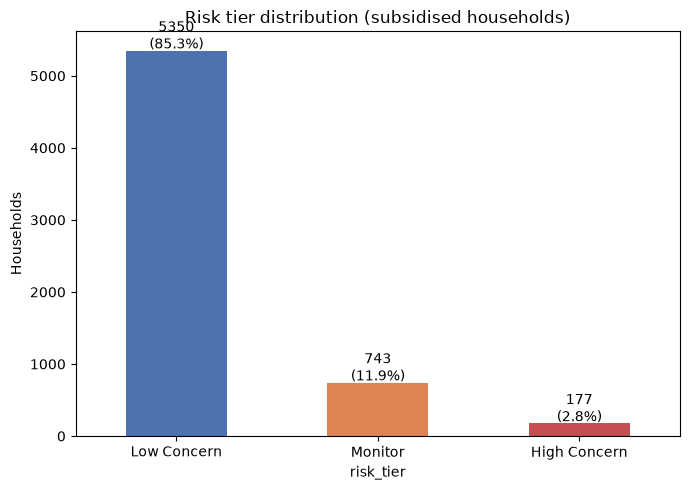

In [18]:
import matplotlib.pyplot as plt

order = ["Low Concern", "Monitor", "High Concern"]
counts = df["risk_tier"].value_counts().reindex(order)

ax = counts.plot.bar(figsize=(7, 5), color=["#4c72b0", "#dd8452", "#c44e52"])
ax.set_ylabel("Households")
ax.set_title("Risk tier distribution (subsidised households)")
ax.set_xticklabels(order, rotation=0)
for i, v in enumerate(counts):                      # label each bar with its count + %
    ax.text(i, v + 30, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
plt.tight_layout(); plt.show()

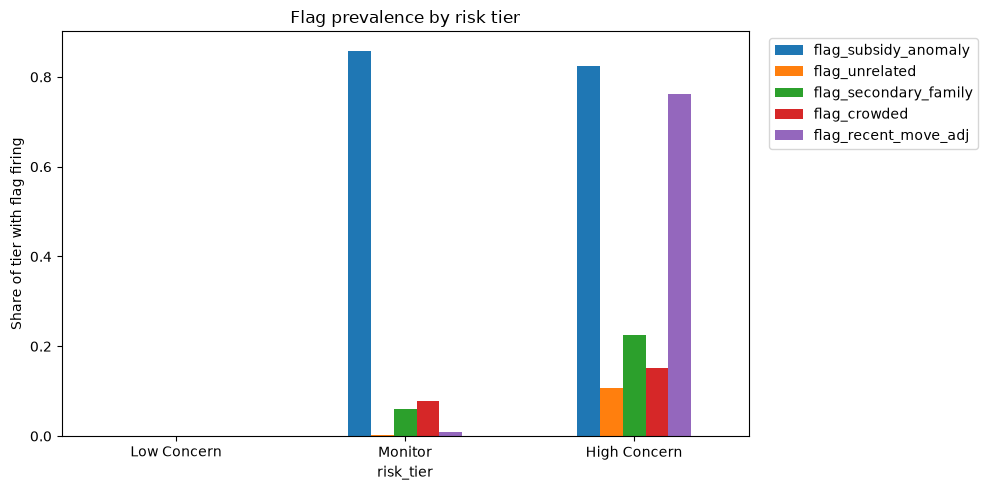

In [19]:
flag_cols = ["flag_subsidy_anomaly", "flag_unrelated", "flag_secondary_family",
             "flag_crowded", "flag_recent_move_adj"]

prevalence = df.groupby("risk_tier")[flag_cols].mean().reindex(order)
prevalence.plot.bar(figsize=(10, 5))
plt.ylabel("Share of tier with flag firing")
plt.title("Flag prevalence by risk tier")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## Modelling approach: avoiding circularity

Our label is a deterministic rule over specific columns. If the model were trained on those same columns it would simply re-learn the rule and report a near-perfect but meaningless score. To keep the evaluation honest, the model is trained **only on features the labelling rule never used** — housing cost, unit structure, subsidy type, and household age composition.

The model therefore answers a genuine, non-trivial question: *can a household's cost and structural profile predict the risk tier its composition and income earned?* A modest score here is the **expected and correct** outcome; a very high score would signal that label information had leaked back into the features. This is tested directly in the contrast experiment near the end.

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline          # NOTE: imblearn's Pipeline, not sklearn's
from imblearn.over_sampling import SMOTE
import pandas as pd

In [21]:
# EXCLUDED because they ARE the label or directly build it — feeding these in
# would let the model reconstruct your rule and score a meaningless high score
#   PERPOVLVL, HINCP, FINCP        -> build flag_subsidy_anomaly
#   NUMNONREL                      -> flag_unrelated
#   NUMSECFAM, NUMSUBFAM           -> flag_secondary_family
#   NUMPEOPLE, TOTROOMS,
#   is_crowded, persons_per_room   -> flag_crowded
#   HHMOVE                         -> flag_recent_move
#   all flag_*, risk_score         -> the label itself
#
# KEPT: cost / structure / subsidy-type / demographic signals that the rule
# never used. The model's real question becomes: can these predict the tier
# a household's composition earned?  (Honest, non-circular.)

feature_cols = [
    "HUDSUB",       # subsidy type (1 = public housing, 2 = voucher)
    "RENT",         # monthly rent
    "TOTHCAMT",     # total housing cost
    "UTILAMT",      # utilities
    "BEDROOMS",     # unit structure
    "MGRONSITE",    # on-site management
    "NUMADULTS", "NUMELDERS", "NUMYNGKIDS", "NUMOLDKIDS",  # household make-up
]

X = df[feature_cols].copy()
y = df["risk_tier"].copy()

X = X.fillna(X.median())        # cost/structure cols are ~complete; this is a safety net
print(X.shape)
print(y.value_counts())

(6270, 10)
risk_tier
Low Concern     5350
Monitor          743
High Concern     177
Name: count, dtype: int64


Two caveats on the feature set. First, the household age counts (`NUMADULTS`, `NUMELDERS`, `NUMYNGKIDS`, `NUMOLDKIDS`) sum toward total occupancy, which partly underlies the overcrowding flag; because `NUMPEOPLE` and `TOTROOMS` are both excluded the crowding ratio cannot be reconstructed, but a weak indirect association remains. Second, the AHS survey weight (`WEIGHT`) is not applied — a standard simplification for a classification exercise, but it means results are not population-weighted estimates.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("train:", y_train.value_counts().to_dict())
print("test: ", y_test.value_counts().to_dict())

train: {'Low Concern': 4012, 'Monitor': 557, 'High Concern': 133}
test:  {'Low Concern': 1338, 'Monitor': 186, 'High Concern': 44}


### Handling imbalance and validation

Classes are **stratified** across the split so the test set preserves the real (~85 / 12 / 3) distribution. **SMOTE is applied inside the pipeline**, so synthetic minority samples are generated only from the training fold during cross-validation and never leak into evaluation. Five models are compared on macro-F1 (equal weight to every tier) and weighted-F1.

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
    "SVM":                  SVC(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("smote", SMOTE(random_state=42)),   # runs on the training portion of each fold only
        ("clf",   clf),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["f1_macro", "f1_weighted"])
    macro = scores["test_f1_macro"].mean()
    weighted = scores["test_f1_weighted"].mean()
    print(f"{name:22s} macro-F1: {macro:.3f}   weighted-F1: {weighted:.3f}")

Logistic Regression    macro-F1: 0.411   weighted-F1: 0.737
Decision Tree          macro-F1: 0.396   weighted-F1: 0.751
Random Forest          macro-F1: 0.432   weighted-F1: 0.783
Gradient Boosting      macro-F1: 0.448   weighted-F1: 0.772
SVM                    macro-F1: 0.415   weighted-F1: 0.744


### Interpreting the results

Macro-F1 across the five models clusters around **0.40–0.45** (Gradient Boosting best, ~0.45). That five very different algorithms land in the same narrow band indicates the ceiling is set by the information in the permitted features, not by model choice.

This modest score is the **honest** consequence of the deliberate feature exclusion above. The per-class breakdown is the real story: *Low Concern* is identified well, while *High Concern* recall is low — because the tiers are driven by composition and eligibility signals the model is not permitted to see, and cost proxies alone carry little of that information. The practical finding is that tenancy-misuse risk, as defined here, is **not reducible to observable cost and structural features** — an informative negative result.

In [24]:
# Gradient Boosting won the model comparison above (macro-F1 ~0.45), so we
# refit it on the full training set and evaluate once on the held-out test set.
best = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf",   GradientBoostingClassifier(random_state=42)),
]).fit(X_train, y_train)

y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=["Low Concern","Monitor","High Concern"]))

              precision    recall  f1-score   support

High Concern       0.10      0.18      0.13        44
 Low Concern       0.92      0.77      0.84      1338
     Monitor       0.26      0.51      0.34       186

    accuracy                           0.73      1568
   macro avg       0.43      0.49      0.44      1568
weighted avg       0.82      0.73      0.76      1568

[[1036  251   51]
 [  73   95   18]
 [  17   19    8]]


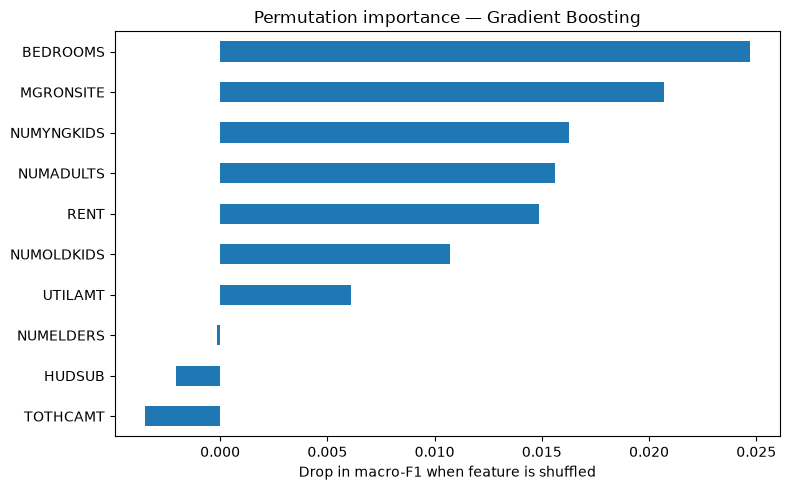

In [25]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

result = permutation_importance(
    best, X_test, y_test, scoring="f1_macro", n_repeats=20, random_state=42
)
imp = pd.Series(result.importances_mean, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
imp.plot.barh()
plt.xlabel("Drop in macro-F1 when feature is shuffled")
plt.title("Permutation importance — Gradient Boosting")
plt.tight_layout(); plt.show()

### Ordinal agreement

Because the tiers are ordered, **quadratic weighted kappa** is reported as a fairer summary than flat multiclass F1: it penalises predictions that are two tiers off far more than adjacent-tier errors, which is the right emphasis for a triage tool.

In [26]:
from sklearn.metrics import cohen_kappa_score
order = {"Low Concern": 0, "Monitor": 1, "High Concern": 2}
qwk = cohen_kappa_score(y_test.map(order), pd.Series(y_pred).map(order), weights="quadratic")
print(f"Quadratic weighted kappa: {qwk:.3f}")

Quadratic weighted kappa: 0.258


### Explainability: decision rules

A shallow decision tree is fitted purely for interpretation, exposing the cost/structure thresholds the model relies on — supporting the requirement that outputs be explainable and suitable for human review.

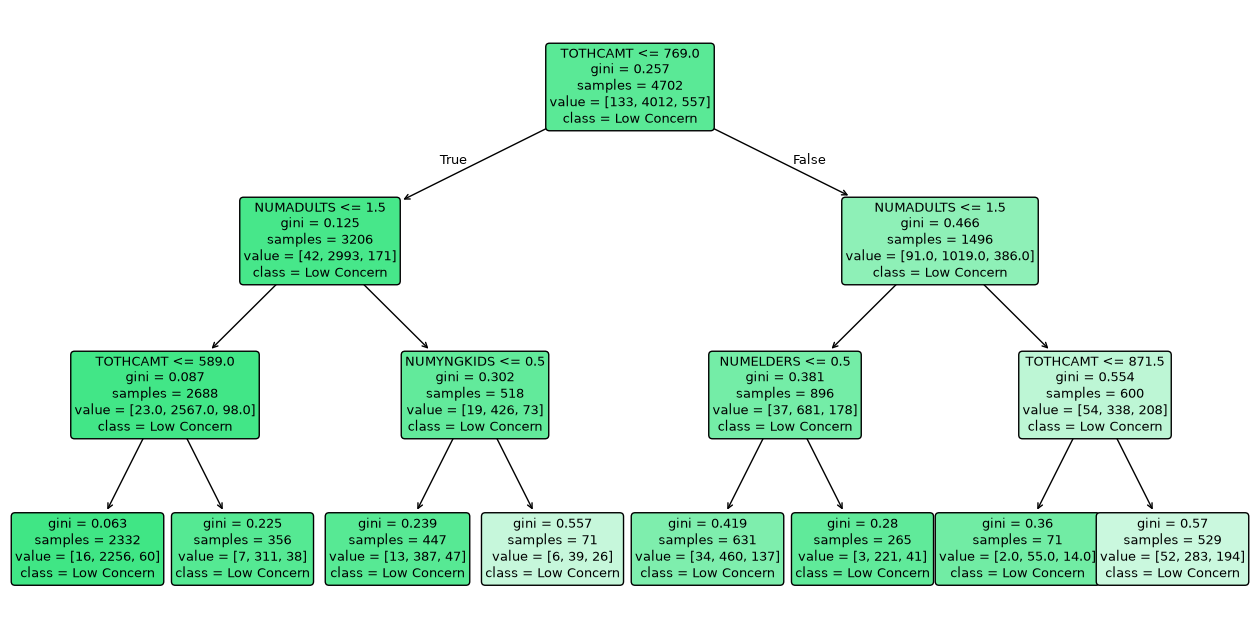

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=feature_cols, class_names=list(dt.classes_),
          filled=True, rounded=True, fontsize=9)
plt.show()

### Confusion matrices

Raw counts are dominated by the large Low Concern class, so the **normalised** panel (per-class recall) is the more informative view. Reading the High Concern row shows where its errors land — mostly in the adjacent Monitor tier rather than in Low Concern, i.e. the model tends to *under-rate* high-risk cases rather than badly misplace them.

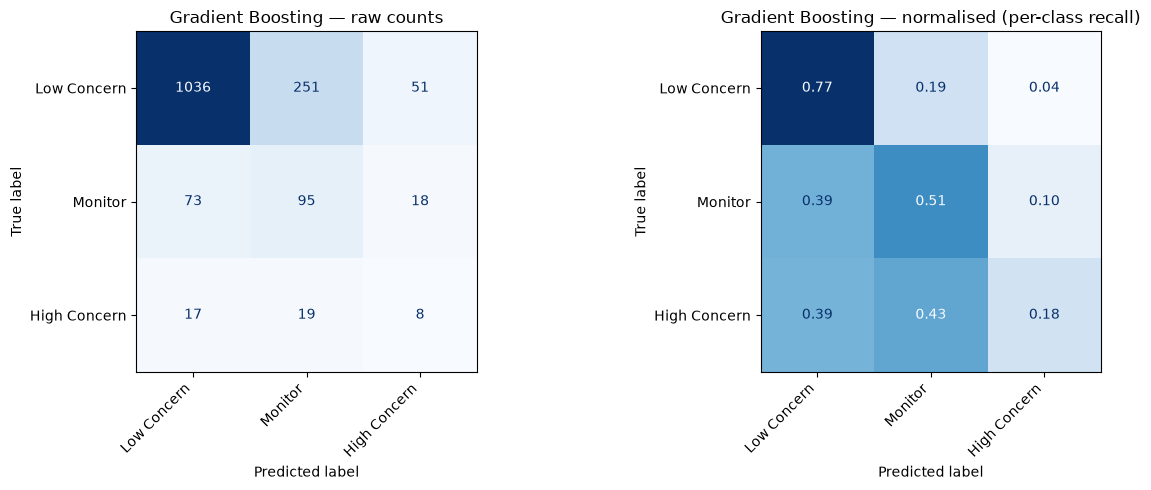

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Low Concern", "Monitor", "High Concern"]

def plot_confusion(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{title} — raw counts")

    cmn = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    ConfusionMatrixDisplay(cmn, display_labels=labels).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[1].set_title(f"{title} — normalised (per-class recall)")

    for ax in axes:
        ax.set_xticklabels(labels, rotation=45, ha="right")
    plt.tight_layout(); plt.show()

plot_confusion(y_test, y_pred, "Gradient Boosting")

### Contrast experiment: quantifying the circularity we avoided

To **demonstrate** rather than merely assert that the honest model avoids circularity, we now train an otherwise identical model that *includes* the label-defining columns. Because the tiers are a deterministic function of these columns, this "leaky" model recovers them almost perfectly. The value is the **gap** between the two scores: it quantifies how much the label depends on its own inputs. This score is a diagnostic only and is never reported as detection accuracy.

In [29]:
# CONTRAST / DIAGNOSTIC ONLY - NOT a headline result.
# We deliberately INCLUDE the label-defining columns as features. Because the
# tiers are a deterministic rule over these columns, the model recovers them
# almost perfectly. The point is the GAP vs the honest model, which quantifies
# how much the tiers depend on their own defining signals. Reporting this as
# "detection accuracy" would BE the circularity the main model avoids.
from sklearn.metrics import f1_score

leaky_cols = feature_cols + [
    "PERPOVLVL", "NUMNONREL", "NUMSECFAM", "NUMSUBFAM",
    "persons_per_room", "HHMOVE",
]

X_leaky = df[leaky_cols].copy()
X_leaky = X_leaky.fillna(X_leaky.median())

# reuse the exact same train/test rows as the honest model for a fair contrast
Xl_train = X_leaky.loc[X_train.index]
Xl_test  = X_leaky.loc[X_test.index]

leaky_model = Pipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf",   GradientBoostingClassifier(random_state=42)),
]).fit(Xl_train, y_train)

leaky_pred   = leaky_model.predict(Xl_test)
honest_macro = f1_score(y_test, y_pred, average="macro")
leaky_macro  = f1_score(y_test, leaky_pred, average="macro")

print(f"Honest model (label features EXCLUDED): macro-F1 = {honest_macro:.3f}")
print(f"Leaky model  (label features INCLUDED): macro-F1 = {leaky_macro:.3f}")
print(f"Gap = {leaky_macro - honest_macro:.3f}")

Honest model (label features EXCLUDED): macro-F1 = 0.439
Leaky model  (label features INCLUDED): macro-F1 = 0.986
Gap = 0.547


### Worked examples for human review

For a sample of High Concern households we show, side by side, the flags that drove the rule's tier and the limited cost/structure information the model actually saw. The disagreement cases make the central finding concrete: risk driven by composition and eligibility is not visible in cost signals alone.

In [30]:
# attach model predictions to the test rows so we can compare rule vs model
test_view = df.loc[X_test.index].copy()
test_view["predicted_tier"] = y_pred          # aligned to X_test row order

flag_labels = {
    "flag_subsidy_anomaly":  "subsidised but high income (eligibility anomaly)",
    "flag_unrelated":        "2+ unrelated adults (possible sub-tenants)",
    "flag_secondary_family": "separate family sharing the unit",
    "flag_crowded":          "overcrowded (>1 person/room)",
    "flag_recent_move_adj":  "recent move compounding another flag",
}

def explain_case(row):
    fired = [d for f, d in flag_labels.items() if row[f] == 1]
    print(f"Household {row.name}")
    print(f"  Rule tier : {row['risk_tier']}  (score {int(row['risk_score'])})")
    print(f"  Model says: {row['predicted_tier']}")
    print(f"  Flags fired: " + ("; ".join(fired) if fired else "none"))
    print(f"  Model saw : rent ${row['RENT']:.0f}, housing ${row['TOTHCAMT']:.0f}, "
          f"{int(row['BEDROOMS'])} bed, {int(row['NUMADULTS'])} adults, "
          f"subsidy type {int(row['HUDSUB'])}")
    if row["risk_tier"] != row["predicted_tier"]:
        print("  -> DISAGREEMENT: risk came from composition/eligibility signals")
        print("     the model can't see; cost/structure alone under-rates it.")
    else:
        print("  -> agreement: cost/structure aligned with the rule tier.")
    print()

# show a few High Concern cases — mix of agreements and disagreements
for _, r in test_view[test_view["risk_tier"] == "High Concern"].head(5).iterrows():
    explain_case(r)

Household 3655
  Rule tier : High Concern  (score 3)
  Model says: High Concern
  Flags fired: separate family sharing the unit; overcrowded (>1 person/room)
  Model saw : rent $2100, housing $2240, 2 bed, 2 adults, subsidy type 2
  -> agreement: cost/structure aligned with the rule tier.

Household 38254
  Rule tier : High Concern  (score 3)
  Model says: Monitor
  Flags fired: subsidised but high income (eligibility anomaly); recent move compounding another flag
  Model saw : rent $1500, housing $1663, 3 bed, 3 adults, subsidy type 2
  -> DISAGREEMENT: risk came from composition/eligibility signals
     the model can't see; cost/structure alone under-rates it.

Household 53929
  Rule tier : High Concern  (score 3)
  Model says: Low Concern
  Flags fired: subsidised but high income (eligibility anomaly); recent move compounding another flag
  Model saw : rent $400, housing $520, 1 bed, 1 adults, subsidy type 1
  -> DISAGREEMENT: risk came from composition/eligibility signals
     the 

## Limitations and conclusion

- **Proxy label, not ground truth.** All results depend on a rule-based label; the model learns our *definition* of risk, not confirmed fraud. Validation on a genuinely labelled fraud dataset, and on anonymised local (HDC) records, is left to future work.
- **Weak subletting signal.** On the subsidised subsample the composition flags are rare; the label is dominated by the eligibility-anomaly signal, so the project speaks more to general subsidised-tenancy misuse than to subletting specifically.
- **Data cannot observe non-occupation.** The strongest real subletting signal — a tenant living elsewhere — is absent from the AHS public file, an inherent ceiling on what this dataset can detect.
- **US proxy for a Maldivian problem.** Findings transfer as methodology, not as calibrated local rates. The survey weight is also unused, so figures are unweighted.

Overall, the pipeline demonstrates a defensible weak-supervision workflow, a leakage-controlled model comparison, and an honest evaluation whose modest scores are themselves an informative result about the limits of profile-based tenancy-risk detection.